In [38]:
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import joblib

In [39]:
# Load Dataset
df = pd.read_csv("../data/Concrete_Data.csv")

In [40]:
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [41]:
print("Dataframe Shape: ", df.shape)
df.info()

Dataframe Shape:  (1030, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MP

In [42]:
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [43]:
df.isnull().sum()

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

In [44]:
columns = df.columns.to_list()
columns

['Cement (component 1)(kg in a m^3 mixture)',
 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
 'Fly Ash (component 3)(kg in a m^3 mixture)',
 'Water  (component 4)(kg in a m^3 mixture)',
 'Superplasticizer (component 5)(kg in a m^3 mixture)',
 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
 'Fine Aggregate (component 7)(kg in a m^3 mixture)',
 'Age (day)',
 'Concrete compressive strength(MPa, megapascals) ']

In [45]:
# Split Feature Matrix and Target Vector

X = df.iloc[:,:-1].values

y = df.iloc[:, -1].values.reshape(-1, 1)

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (1030, 8)
Target shape: (1030, 1)


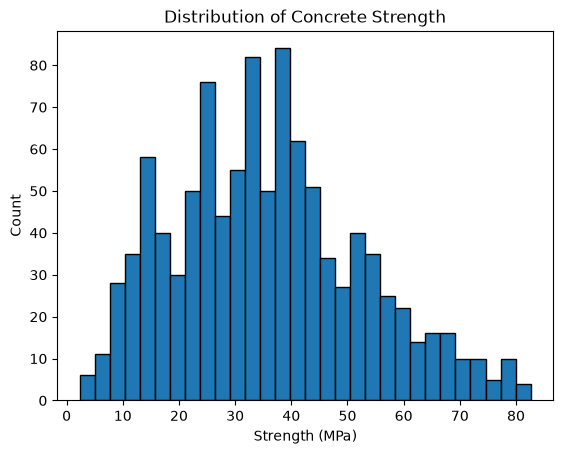

In [46]:
# Plot histogram for the target variable (Concrete Strength)
plt.hist(y, bins=30, edgecolor='k')
plt.title('Distribution of Concrete Strength')
plt.xlabel('Strength (MPa)')
plt.ylabel('Count')
plt.show()

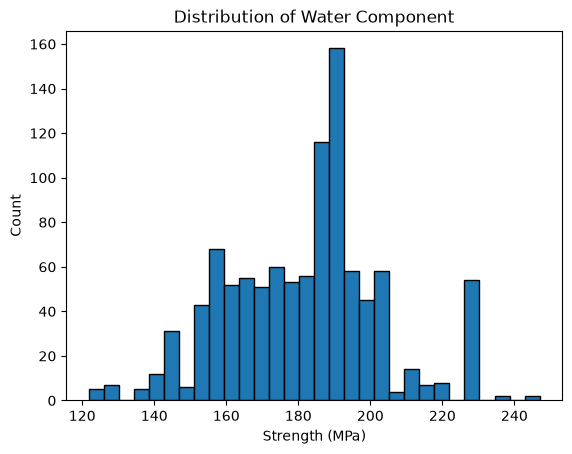

In [47]:
# Plot histogram for the Water Component

water_feature = df["Water  (component 4)(kg in a m^3 mixture)"]

plt.hist(water_feature, bins=30, edgecolor='k')
plt.title('Distribution of Water Component')
plt.xlabel('Strength (MPa)')
plt.ylabel('Count')
plt.show()

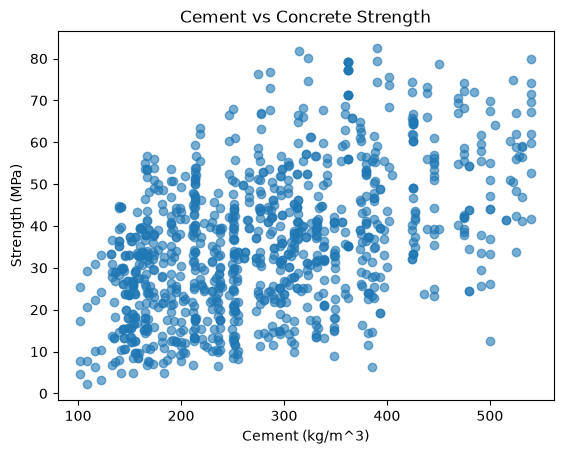

In [48]:
# Scatterplot: Cement vs Concrete Strength
plt.scatter(df['Cement (component 1)(kg in a m^3 mixture)'], y, alpha=0.6)
plt.title('Cement vs Concrete Strength')
plt.xlabel('Cement (kg/m^3)')
plt.ylabel('Strength (MPa)')
plt.show()

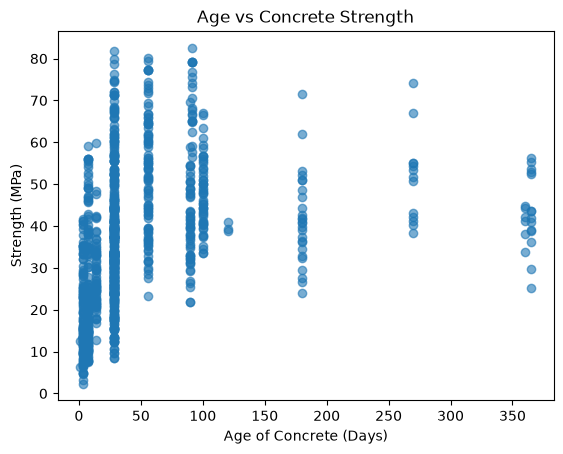

In [49]:
# Scatterplot: Age vs Concrete Strength
plt.scatter(df["Age (day)"], y, alpha=0.6)
plt.title('Age vs Concrete Strength')
plt.xlabel('Age of Concrete (Days)')
plt.ylabel('Strength (MPa)')
plt.show()

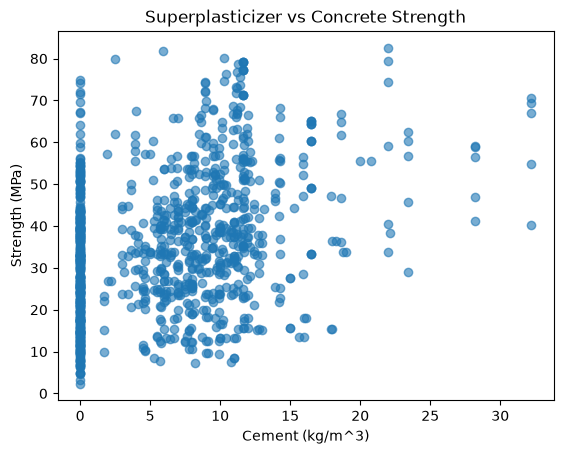

In [50]:
# Scatterplot: Superplasticizer vs Concrete Strength
plt.scatter(df["Superplasticizer (component 5)(kg in a m^3 mixture)"], y, alpha=0.6)
plt.title('Superplasticizer vs Concrete Strength')
plt.xlabel('Cement (kg/m^3)')
plt.ylabel('Strength (MPa)')
plt.show()

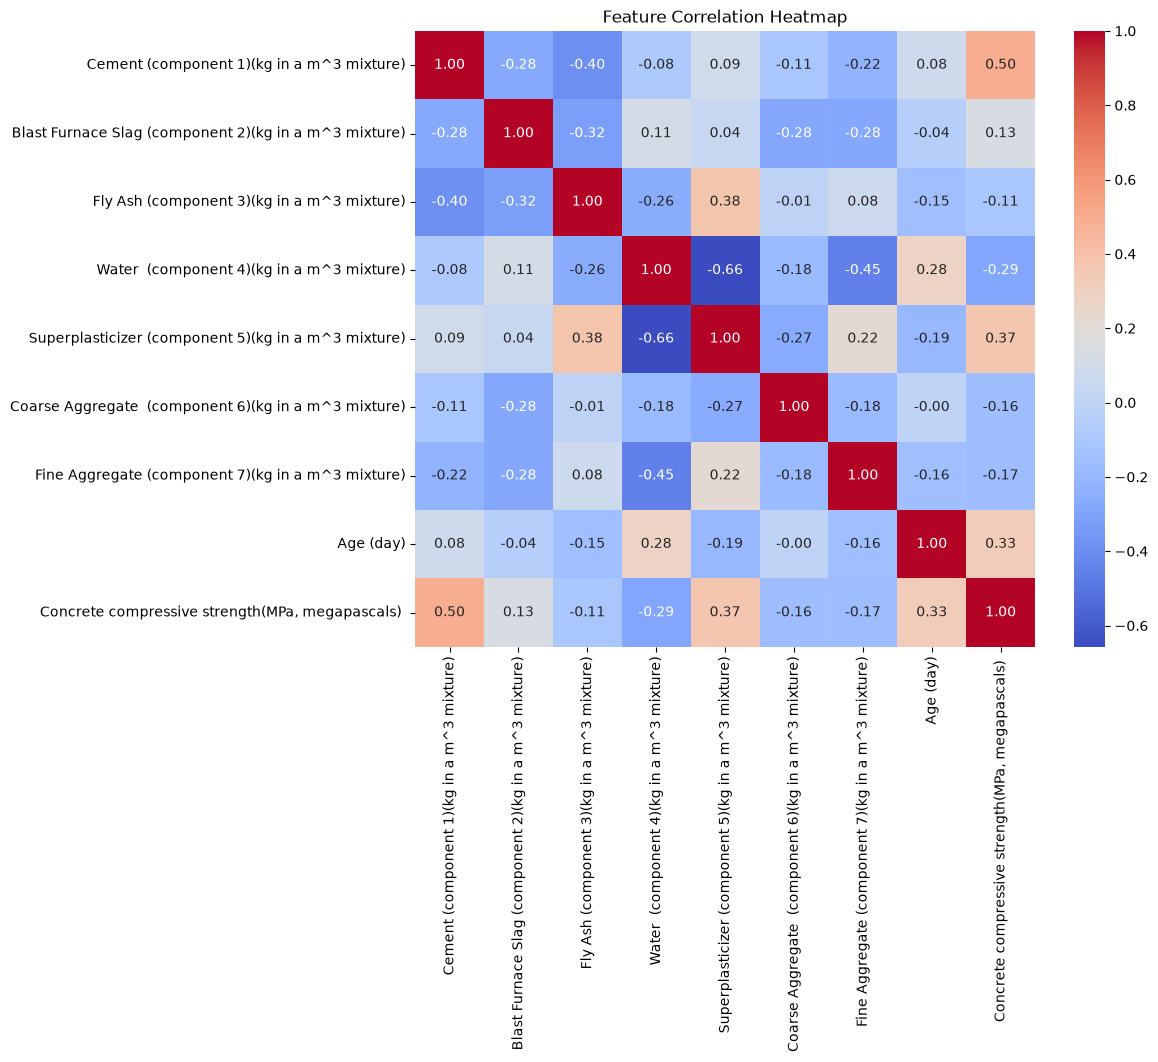

In [51]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [52]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [53]:
# Scale features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Linear Regression

In [54]:
# Linear Regression Model

model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 8)","[[12.79, 9.43, 5.25,..., 1.41, 1.95, 7.04]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[35.86]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[42.98,34.36,33.31,...,25.6 ,12.32, 5.06]"


In [55]:
# Prediction

lr_pred = model_lr.predict(X_test_scaled)
lr_mse = mean_squared_error(lr_pred, y_test)
lr_r2 = r2_score(lr_pred, y_test)

print("=== Linear Regression ===")
print(f"MSE : {lr_mse:.2f}")
print(f"RMSE: {np.sqrt(lr_mse):.2f}")
print(f"R²  : {lr_r2:.4f}")

=== Linear Regression ===
MSE : 95.97
RMSE: 9.80
R²  : 0.4232


### Multi Layer Perceptron

In [56]:
# Convert to PyTorch tensors
# X is float32 because neural network weights are float32
# y needs reshape(-1, 1) because our model outputs shape (n, 1) not (n,)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).reshape(-1, 1)

print(X_train_tensor.shape)  # Should be (824, 8)
print(y_train_tensor.shape)  # Should be (824, 1)

torch.Size([824, 8])
torch.Size([824, 1])


In [57]:
# Custom MLP class for regression
class ConcreteMLP(nn.Module):
    def __init__(self, input_size=8, hidden_size=16, output_size=1):
        super(ConcreteMLP, self).__init__()
        
        self.fc1 = nn.Linear(input_size, hidden_size)  # First hidden layer
        self.relu = nn.ReLU()                          # Activation
        self.fc2 = nn.Linear(hidden_size, output_size) # Output layer
    
    def forward(self, x):
        x = self.fc1(x)   # Apply first linear layer
        x = self.relu(x)  # Apply ReLU activation
        x = self.fc2(x)   # Apply output layer
        return x

# Create model instance
model = ConcreteMLP()
print(model)

ConcreteMLP(
  (fc1): Linear(in_features=8, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


In [58]:
import torch.optim as optim

# Instantiate the model
model = ConcreteMLP()

# Define the loss function
loss_fn = nn.MSELoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)
print(optimizer)

ConcreteMLP(
  (fc1): Linear(in_features=8, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [59]:
# Number of training epochs
num_epochs = 1000

# List to store loss values per epoch
train_losses = []

# Training loop
for epoch in range(num_epochs):

    # ===== Zero Gradients =====
    optimizer.zero_grad()   # ← zero first, THEN forward pass

    # ===== Forward Pass =====
    y_pred = model(X_train_tensor)

    # ===== Compute Loss =====
    loss = loss_fn(y_pred, y_train_tensor)

    # ===== Backward Pass =====
    loss.backward()

    # ===== Optimizer Step =====
    optimizer.step()    

    # ===== Record Loss =====
    train_losses.append(loss.item())

    # ===== Print Occasionally =====
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [50/1000], Loss: 948.9563
Epoch [100/1000], Loss: 249.3427
Epoch [150/1000], Loss: 171.8446
Epoch [200/1000], Loss: 146.9388
Epoch [250/1000], Loss: 135.5006
Epoch [300/1000], Loss: 126.6833
Epoch [350/1000], Loss: 120.1386
Epoch [400/1000], Loss: 114.8566
Epoch [450/1000], Loss: 109.6463
Epoch [500/1000], Loss: 96.0606
Epoch [550/1000], Loss: 76.3229
Epoch [600/1000], Loss: 61.9890
Epoch [650/1000], Loss: 53.5765
Epoch [700/1000], Loss: 49.2439
Epoch [750/1000], Loss: 46.0271
Epoch [800/1000], Loss: 44.1520
Epoch [850/1000], Loss: 42.9943
Epoch [900/1000], Loss: 42.3712
Epoch [950/1000], Loss: 41.9691
Epoch [1000/1000], Loss: 41.6773


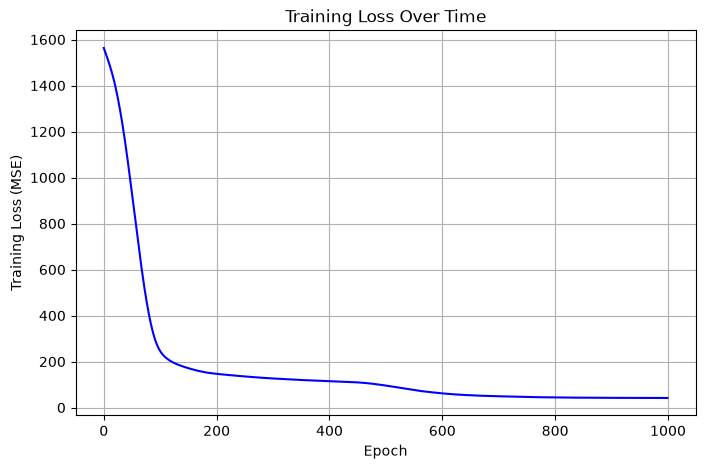

In [60]:
# Plot the training loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(num_epochs), train_losses, linestyle='-', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Training Loss (MSE)')
plt.title('Training Loss Over Time')
plt.grid(True)
plt.show()

In [61]:
# Evaluate model performance
model.eval()  # Switch model to evaluation mode (disables dropout etc. if any)

with torch.no_grad():
    # Predict on train set
    train_preds = model(X_train_tensor)
    train_loss = loss_fn(train_preds, y_train_tensor)

    # Predict on test set
    test_preds = model(X_test_tensor)
    test_loss = loss_fn(test_preds, y_test_tensor)

print(f"Final Training Loss (MSE): {train_loss.item():.4f}")
print(f"Final Testing Loss (MSE): {test_loss.item():.4f}")

Final Training Loss (MSE): 41.6725
Final Testing Loss (MSE): 46.4113


In [62]:
# Saving Models

# ── 1. Save Linear Regression model ──────────────────────────────
joblib.dump(model_lr, '../models/linear_regression.pkl')
print("✓ Linear Regression saved  →  models/linear_regression.pkl")

# ── 2. Save the Scaler ───────────────────────────────────────────
joblib.dump(scaler, '../models/scaler.pkl')
print("✓ Scaler saved             →  models/scaler.pkl")

# ── 3. Save PyTorch MLP weights ──────────────────────────────────
torch.save(model.state_dict(), '../models/mlp_model.pth')
print("✓ MLP weights saved        →  models/mlp_model.pth")

✓ Linear Regression saved  →  models/linear_regression.pkl
✓ Scaler saved             →  models/scaler.pkl
✓ MLP weights saved        →  models/mlp_model.pth
